2026-01-15 14-58-17
Outputs will be written to: results/run_2026-01-15 14-58-17
Saved a copy of the config : results/run_2026-01-15 14-58-17/config_copy.yaml
Inputs shape: (21, 2)
Outputs shape: (21,)
First 20 rows of raw data:
    number-1  number-2  log-likelyhood-score   source
9   0.702637  0.926564              0.611205     file
17  0.715000  0.950000              0.597629   week-8
13  0.691873  0.263356              0.596081   week-4
20  0.721765  0.565232              0.570096  week-11
18  0.720000  0.950000              0.565857   week-9
0   0.665800  0.123969              0.538996     file
12  0.722766  0.839711              0.533827   week-3
19  0.658567  0.384858              0.490274  week-10
1   0.877791  0.778628              0.420586     file
3   0.845275  0.711120              0.293993     file
6   0.438166  0.685018              0.244619     file
4   0.454647  0.290455              0.214965     file
11  0.616162  1.000000              0.180119   week-2
10  0.818182  0.

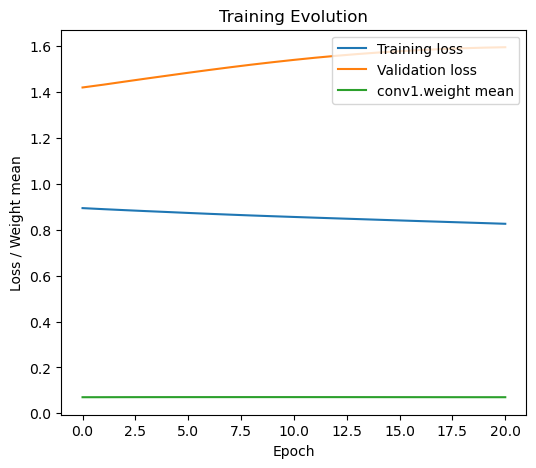

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
sample_strategy=sobol, Final sample shape: (1000000, 2)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.04320637, 1.09932312]), 'score': 0.004315859891143598, 'dim': 2, 'predicted_y': 0.26717064, 'improvement_over_input_model': -0.00083243847, 'distance_to_best_input': 0.5815008473370135}
{'method': 'PI', 'xi': 0.2, 'kappa': None, 'x': array([0.04320637, 1.09932312]), 'score': 0.0025471549040456667, 'dim': 2, 'predicted_y': 0.26717064, 'improvement_over_input_model': -0.00083243847, 'distance_to_best_input': 0.5815008473370135}
{'method': 'PI', 'xi': 0.5, 'kappa': None, 'x': array([0.04320637, 1.09932312]), 'score': 0.00044190560706870854, 'dim': 2, 'predicted_y': 0.26717064, 'improvement_ove

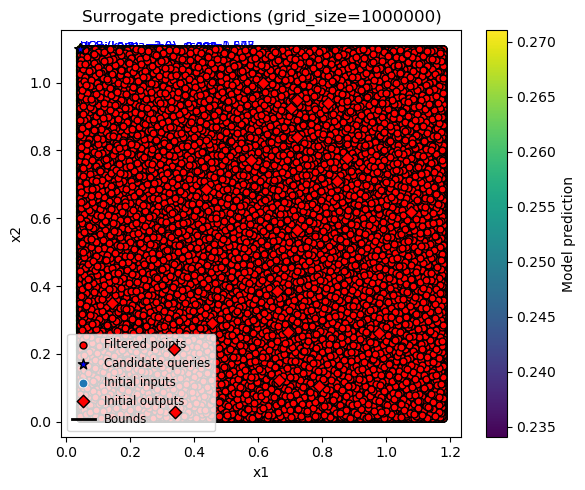

Saved dataframe to: results/run_2026-01-15 14-58-17/df_grid_1000000_stride1_None_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.04320637, 1.09932312]), 'score': 1.6469691533856814, 'dim': 2, 'predicted_y': 0.26717064, 'improvement_over_input_model': -0.00083243847, 'distance_to_best_input': 0.5815008473370135, 'best_input_x': array([0.616162, 1.      ]), 'best_input_pred': 0.26800308}
    number-1  number-2  log-likelyhood-score   source  log-likelyhood-score-scaled
0   0.043206  1.099323              1.646969   week-x                    10.000000
1   0.043206  1.099323              1.074569   week-x                     6.524526
2   0.702637  0.926564              0.611205     file                     3.711091
3   0.715000  0.950000              0.597629   week-8                     3.628662
4   0.691873  0.263356              0.596081   week-4                     3.619262
5   0.721765  0.565232              0.570096  week-11        

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))